In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('clean_weather.csv',index_col=0)
data.ffill()

,tmax,tmin,rain,tmax_tomorrow
1970-01-01,60.0,35.0,0.0,52.0
1970-01-02,52.0,39.0,0.0,52.0
1970-01-03,52.0,35.0,0.0,53.0
1970-01-04,53.0,36.0,0.0,52.0
1970-01-05,52.0,35.0,0.0,50.0
...,...,...,...,...
2022-11-22,62.0,35.0,0.0,67.0
2022-11-23,67.0,38.0,0.0,66.0
2022-11-24,66.0,41.0,0.0,70.0
2022-11-25,70.0,39.0,0.0,62.0


<Axes: xlabel='tmax', ylabel='tmax_tomorrow'>

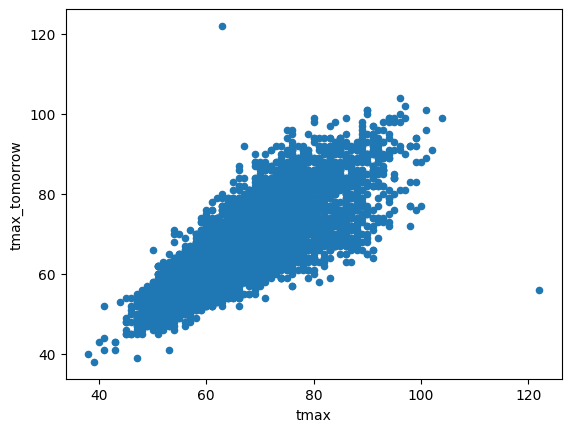

In [4]:
data.plot.scatter('tmax','tmax_tomorrow')

In [6]:
data.corr()

,tmax,tmin,rain,tmax_tomorrow
tmax,1.000000,0.615134,-0.221703,0.818820
tmin,0.615134,1.000000,-0.018215,0.584958
rain,-0.221703,-0.018215,1.000000,-0.213239
tmax_tomorrow,0.818820,0.584958,-0.213239,1.000000


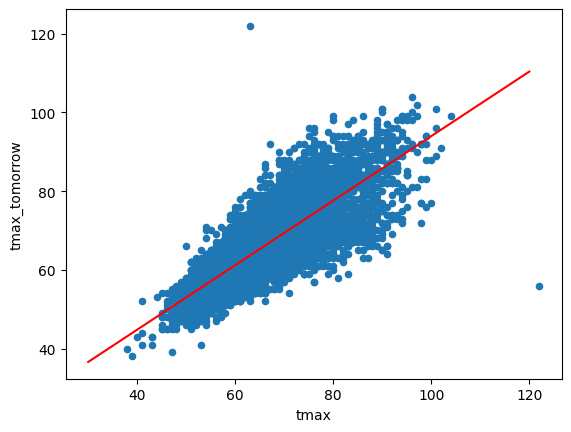

In [12]:
data.plot.scatter('tmax','tmax_tomorrow')
prediction=lambda x,w1=.82,b=11.99: x*w1+b
plt.plot([30,120],[prediction(30),prediction(120)],'red')

In [13]:
def mse(actual,prediction):
    loss=np.mean((actual-prediction)**2)
    return loss

In [18]:
print(mse(data.tmax_tomorrow,prediction(data.tmax,.83)))
print(mse(data.tmax_tomorrow,prediction(data.tmax,.82,12)))
print(mse(data.tmax_tomorrow,prediction(data.tmax,.82,11.9997)))


23.407670993328388
22.83185959970348
22.8317930332172


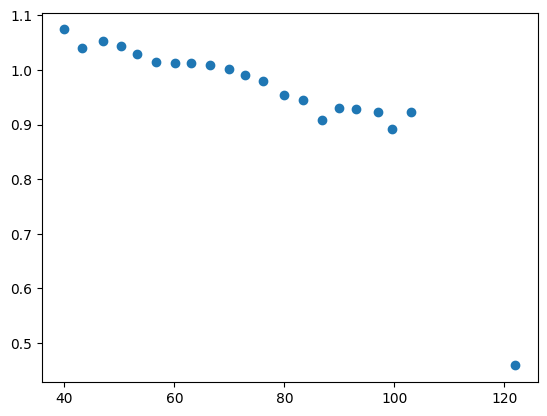

In [39]:
tmax_bins=pd.cut(data.tmax,25)

ratios=(data['tmax_tomorrow']) / data['tmax']
binned_ratio= ratios.groupby(tmax_bins).mean()
binned_tmax=data['tmax'].groupby(tmax_bins).mean()
plt.scatter(binned_tmax,binned_ratio)

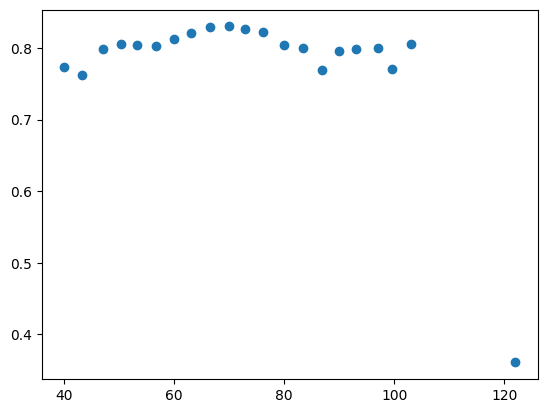

In [37]:
plt.scatter(binned_tmax,binned_ratio)

In [46]:
def relu(value):
    if not value>0:
        value=0
    return value
    

In [49]:
relu(3)

3

In [51]:
80*.82

65.6

#Code


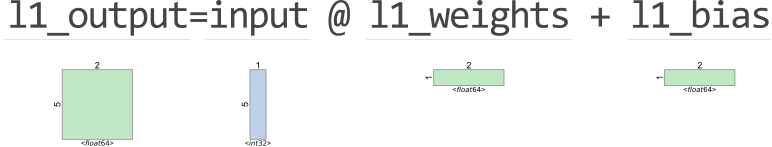

In [63]:
import tsensor

input=np.array([[80],[90],[100],[-20],[-10]])

l1_weights=np.array([[.81,.1]])
l1_bias=np.array([[11.99,10]])

with tsensor.explain(fontsize=40):
    l1_output=input @ l1_weights + l1_bias

In [73]:
l1_activated=np.maximum(l1_output,0)
l1_activated

array([[76.79, 18.  ],
       [84.89, 19.  ],
       [92.99, 20.  ],
       [ 0.  ,  8.  ],
       [ 3.89,  9.  ]])

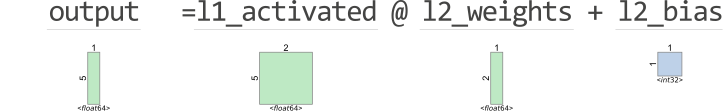

array([[46.995],
       [51.245],
       [55.495],
       [ 6.6  ],
       [ 8.745]])

In [76]:
l2_weights=np.array([[.5],[.2]])
l2_bias=np.array([[5]])

with tsensor.explain(fontsize=30):
    output=l1_activated @ l2_weights + l2_bias
output

In [77]:
tmax = np.array([[80], [90], [100], [-20], [-10]])
tmax_tomorrow = np.array([[83], [89], [95], [-22], [-9]])

In [78]:
def mse(actual, predicted):
    return (actual - predicted) ** 2

In [79]:
def mse_grad(actual, predicted):
    return predicted - actual

mse_grad(tmax_tomorrow, output)

array([[-36.005],
       [-37.755],
       [-39.505],
       [ 28.6  ],
       [ 17.745]])

In [81]:
output_gradient=mse_grad(tmax_tomorrow,output)
output_gradient

array([[-36.005],
       [-37.755],
       [-39.505],
       [ 28.6  ],
       [ 17.745]])

In [84]:
l1_activated.T @ output_gradient

array([[-9574.3878],
       [-1767.03  ]])

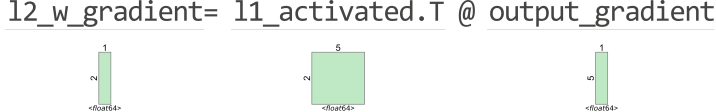

: 

In [89]:
from tsensor import explain as exp

with exp(fontsize=30):
    l2_w_gradient= l1_activated.T @ output_gradient

